### Step 1: Extract Image Features using VGG16

In [1]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import pickle


In [2]:
# Paths
image_dir = os.path.join('..', 'Dataset', 'artefact2', 'train')  # 'data/images'
output_csv = 'features_20250802/vgg16_features.csv'
vgg16_model_path = 'models_20250802/vgg16_model.h5'
os.makedirs('features_20250802', exist_ok=True)
os.makedirs('models_20250802', exist_ok=True)

In [3]:
# Load VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
base_model.save(vgg16_model_path)

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [4]:
features = []
labels = []

# Walk through each class folder
for label in os.listdir(image_dir):
    class_dir = os.path.join(image_dir, label)
    if os.path.isdir(class_dir):
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            try:
                img = image.load_img(img_path, target_size=(224, 224))
                img_array = image.img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)
                feature = base_model.predict(img_array)[0]
                features.append(feature)
                labels.append(label)
            except:
                continue

# Save features with labels
df = pd.DataFrame(features)
df['label'] = labels
df.to_csv(output_csv, index=False)

1/1 [==============================] - 0s 269ms/step


1/1 [==============================] - 0s 272ms/step


1/1 [==============================] - 0s 268ms/step


### Step 2: DCGAN for Feature Generation

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np


In [6]:
# Load features
df = pd.read_csv('features_20250802/vgg16_features.csv')
features = df.drop('label', axis=1).values
labels = df['label'].values
le = LabelEncoder()
labels_enc = le.fit_transform(labels)

# # Normalize features between -1 and 1
# features = (features - features.min()) / (features.max() - features.min())
# features = (features - 0.5) * 2

In [7]:
# GAN config
latent_dim = 100
feature_dim = features.shape[1] # 512

def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, input_dim=latent_dim, activation='relu'),
        # layers.Dense(feature_dim, activation='tanh')
        layers.Dense(feature_dim, activation='linear')
    ])
    return model

def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(128, input_shape=(feature_dim,), activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

gan_input = layers.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = models.Model(gan_input, gan_output)
gan.compile( optimizer='adam', loss='binary_crossentropy')

In [8]:
# Training DCGAN
epochs = 1 # 1000
batch_size = 64
for epoch in range(epochs):
    idx = np.random.randint(0, features.shape[0], batch_size)
    real = features[idx]
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake = generator.predict(noise)

    d_loss_real = discriminator.train_on_batch(real, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # print(f"d_loss_real : {d_loss_real} | d_loss_fake : {d_loss_fake}")
    # print(f"d_loss -> {d_loss} | {100*d_loss[1]:.2f}")
    if epoch % 10 == 0:
        # print(f'Epoch {epoch}, D Loss: {d_loss_real + d_loss_fake:.4f}, G Loss: {g_loss:.4f}')
        print(f"Epoch {epoch} [D loss: {d_loss[0]} | D acc.: {100*d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")


2/2 [==============================] - 0s 5ms/step


Epoch 0 [D loss: 0.9887339323759079 | D acc.: 75.78] [G loss: 1.0471]


In [9]:
# Save models
generator.save('models_20250802/dcgan_generator.h5')
discriminator.save('models_20250802/dcgan_discriminator.h5')

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
# Generate synthetic features
num_samples = 1000
noise = np.random.normal(0, 1, (num_samples, latent_dim))
synthetic_features = generator.predict(noise)

# Randomly assign labels from original
synthetic_labels = np.random.choice(labels, num_samples)
df_gen = pd.DataFrame(synthetic_features)
df_gen['label'] = synthetic_labels
df_gen.to_csv('features_20250802/dcgan_features.csv', index=False)

32/32 [==============================] - 0s 2ms/step


### Step 3: Train Traditional ML Models

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, cohen_kappa_score, log_loss

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Load generated data
df = pd.read_csv('features_20250802/dcgan_features.csv')
X = df.drop('label', axis=1).values
y = df['label'].values

# Label encode
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
with open('models_20250802/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [13]:
# X_scaled.shape, y_encoded.shape # -> ((1000, 512), (1000,))
# print(y_encoded)

# Reverse the label encoding
decoded_data = le.inverse_transform(y_encoded)
# print(f"Decoded data: {decoded_data}")

for v in sorted(list(set(zip(y_encoded, decoded_data)))): print(v)

(0, 'bear')
(1, 'blue_whale')
(2, 'bobcat')
(3, 'cow')
(4, 'dolphin')
(5, 'gorilla')
(6, 'killer_whale')
(7, 'lion')
(8, 'monkey')
(9, 'mouse')
(10, 'ox')
(11, 'rabbit')
(12, 'rhinoceros')
(13, 'siamese_cat')
(14, 'skunk')
(15, 'squirrel')
(16, 'tiger')
(17, 'walrus')


In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [15]:
models = {    
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "AdaBoost": AdaBoostClassifier(),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}


Logistic Regression :

Accuracy : 0.065
Loss : 0.935
Kappa : 0.008062805007426177

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.14      0.15         7
           1       0.08      0.09      0.09        11
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        12
           5       0.08      0.11      0.10         9
           6       0.20      0.11      0.14         9
           7       0.11      0.10      0.11        10
           8       0.11      0.08      0.10        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        12
          12       0.21      0.21      0.21        14
          13       0.06      0.08      0.06        13
          14       0.11      0.10      0.11        10
       

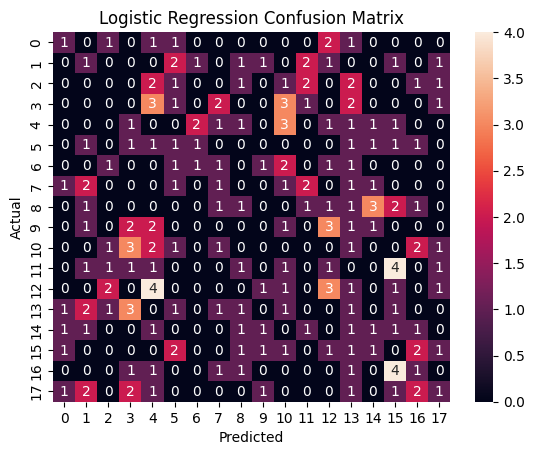


SVM :

Accuracy : 0.065
Loss : 0.935
Kappa : 0.0023740297153831413

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        11
           2       0.07      0.09      0.08        11
           3       0.04      0.08      0.05        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.06      0.08      0.07        12
           9       0.00      0.00      0.00        11
          10       0.08      0.08      0.08        12
          11       0.00      0.00      0.00        12
          12       0.11      0.29      0.16        14
          13       0.12      0.31      0.17        13
          14       0.00      0.00      0.00        10
          15       0.05      0.08     

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

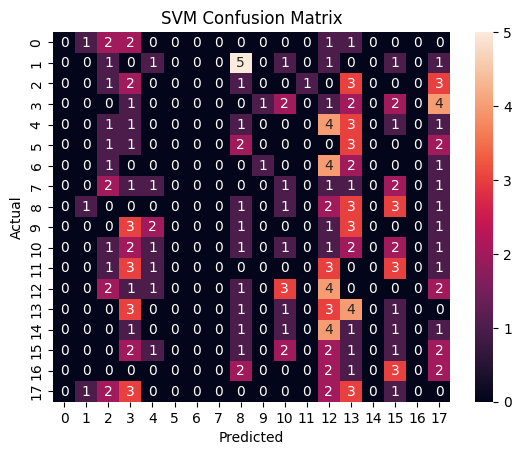


Decision Tree :

Accuracy : 0.03
Loss : 0.97
Kappa : -0.028850233347475607

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.11      0.09      0.10        11
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        12
           5       0.12      0.11      0.12         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.14      0.08      0.11        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.08      0.08      0.08        12
          12       0.07      0.07      0.07        14
          13       0.00      0.00      0.00        13
          14       0.00      0.00      0.00        10
          15       0

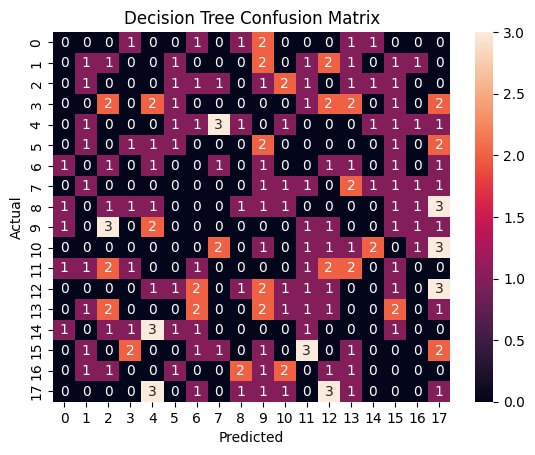


Random Forest :

Accuracy : 0.04
Loss : 0.96
Kappa : -0.02076078577314666

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.07      0.09      0.08        11
           2       0.06      0.09      0.07        11
           3       0.12      0.15      0.13        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.22      0.17      0.19        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.14      0.08      0.11        12
          12       0.00      0.00      0.00        14
          13       0.00      0.00      0.00        13
          14       0.00      0.00      0.00        10
          15       0.

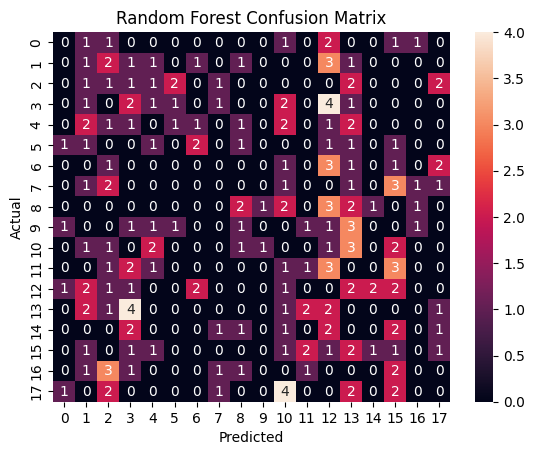


Gradient Boosting :

Accuracy : 0.03
Loss : 0.97
Kappa : -0.030106727552700052

Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        11
           2       0.12      0.09      0.11        11
           3       0.05      0.08      0.06        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.12      0.08      0.10        12
          12       0.00      0.00      0.00        14
          13       0.04      0.08      0.05        13
          14       0.00      0.00      0.00        10
          15

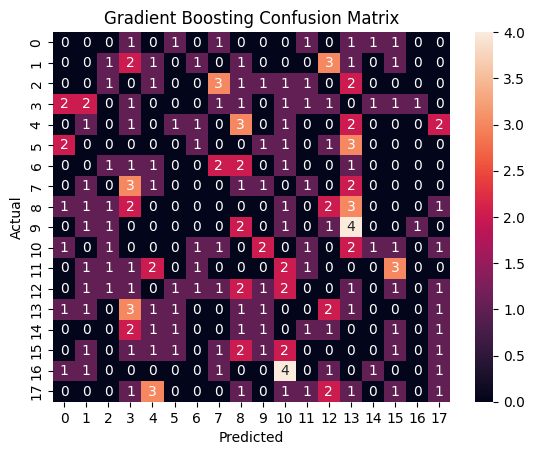


XGBoost :

Accuracy : 0.045
Loss : 0.955
Kappa : -0.012859604931724888

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.18      0.18      0.18        11
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        12
          12       0.16      0.21      0.18        14
          13       0.11      0.15      0.13        13
          14       0.08      0.10      0.09        10
          15       0.04      0

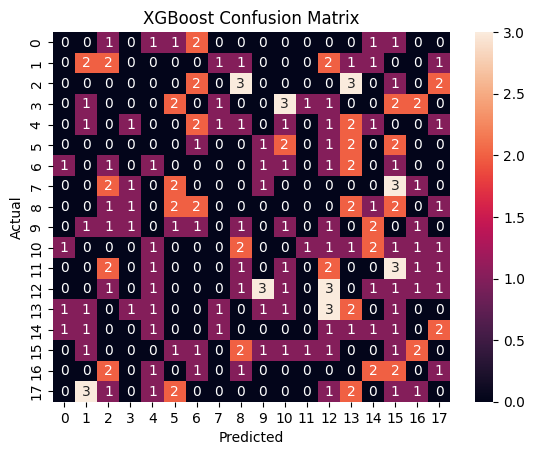


LightGBM :

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014031 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130560
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 512
[LightGBM] [Info] Start training from score -3.317316
[LightGBM] [Info] Start training from score -2.923412
[LightGBM] [Info] Start training from score -2.877949
[LightGBM] [Info] Start training from score -2.714320
[LightGBM] [Info] Start training from score -2.834464
[LightGBM] [Info] Start training from score -3.101093
[LightGBM] [Info] Start training from score -3.073694
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.792791
[LightGBM] [Info] Start training from score -2.923412
[LightGBM] [Info] Start training from score -2.834464
[LightGBM] [Info] Start training from score -2.877949
[LightGBM] [Info] Start training from score -2.67

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

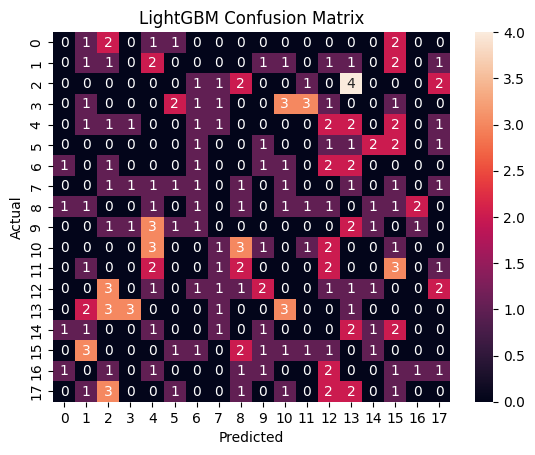


CatBoost :

Accuracy : 0.05
Loss : 0.95
Kappa : -0.009752079292110638

CatBoost Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.10      0.09      0.10        11
           2       0.00      0.00      0.00        11
           3       0.09      0.08      0.08        13
           4       0.06      0.08      0.07        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.09      0.08      0.09        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        12
          12       0.10      0.14      0.11        14
          13       0.05      0.08      0.06        13
          14       0.00      0.00      0.00        10
          15       0.08      0

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

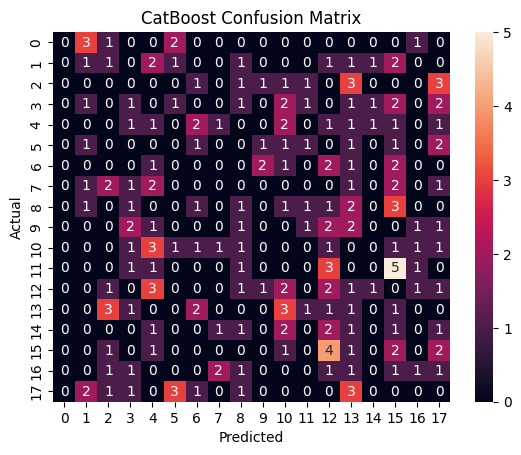


AdaBoost :

Accuracy : 0.06
Loss : 0.94
Kappa : -0.0042198600502108

AdaBoost Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.07      0.08      0.08        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        12
          12       0.07      0.64      0.12        14
          13       0.00      0.00      0.00        13
          14       0.00      0.00      0.00        10
          15       0.00      0.0

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

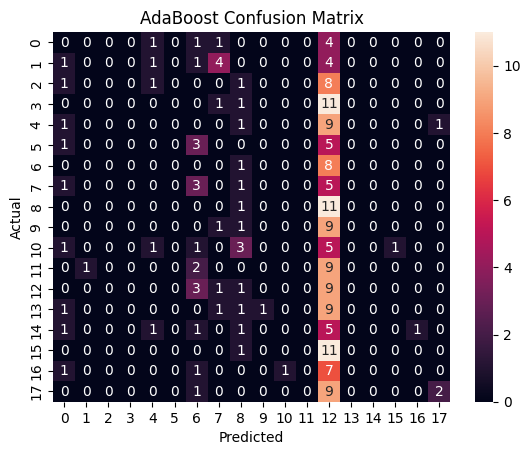


k-NN :

Accuracy : 0.055
Loss : 0.945
Kappa : -0.0007147962830593713

k-NN Classification Report:

              precision    recall  f1-score   support

           0       0.10      0.29      0.14         7
           1       0.10      0.27      0.14        11
           2       0.04      0.09      0.06        11
           3       0.07      0.08      0.07        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        10
           8       0.17      0.08      0.11        12
           9       0.00      0.00      0.00        11
          10       0.06      0.08      0.07        12
          11       0.00      0.00      0.00        12
          12       0.07      0.07      0.07        14
          13       0.00      0.00      0.00        13
          14       0.00      0.00      0.00        10
          15       0.08      0.08  

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

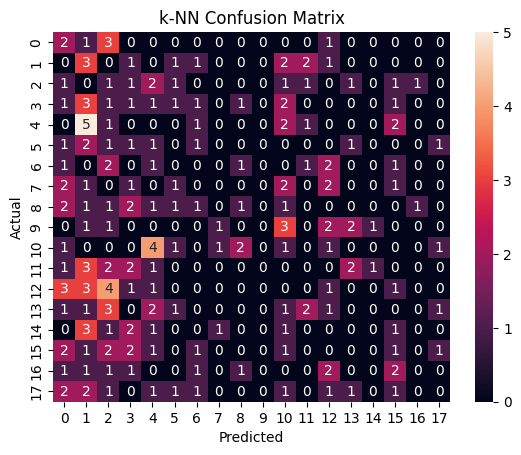


Naive Bayes :

Accuracy : 0.05
Loss : 0.95
Kappa : -0.0064892067275859056

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.08      0.09      0.08        11
           2       0.00      0.00      0.00        11
           3       0.17      0.08      0.11        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         9
           6       0.07      0.11      0.09         9
           7       0.00      0.00      0.00        10
           8       0.17      0.17      0.17        12
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        12
          12       0.00      0.00      0.00        14
          13       0.13      0.15      0.14        13
          14       0.20      0.10      0.13        10
          15       0.05

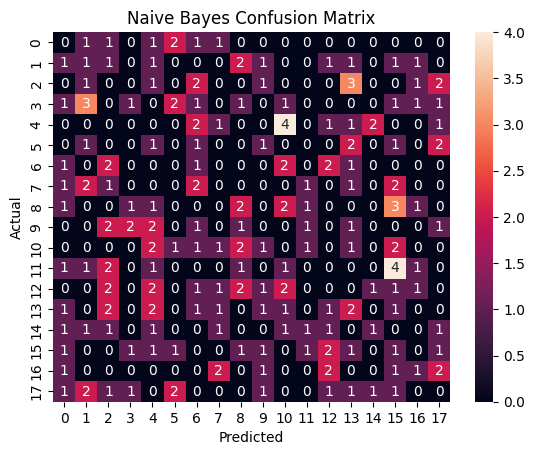

In [16]:
# Train and evaluate
for name, model in models.items():
    print(f"\n{name} :\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy : {accuracy}")
    loss = 1 - accuracy
    print(f"Loss : {loss}")
#     precision = precision_score(y_test, y_pred, average='weighted')
#     print(f"Precision : {precision}")
#     recall = recall_score(y_test, y_pred, average='weighted')
#     print(f"Recall : {recall }")
#     f1 = f1_score(y_test, y_pred, average='weighted')
#     print(f"F1 : {f1}")
    kappa = cohen_kappa_score(y_test, y_pred)
    print(f"Kappa : {kappa}")
    
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Save model
    with open(f'models_20250802/model_{name.lower()}.pkl', 'wb') as f:
        pickle.dump(model, f)